# Hospital Quality vs. Spending

This is a personal research project. I wanted to combine several real analyst skills — Python data cleaning, relational data joins, and building an interactive Power BI dashboard — into one complete, end-to-end piece of work.

I imagined a realistic (but made-up) situation: a Director of Operations asking me to "look at our healthcare data and show what's going on" — vague on purpose, the same kind of open-ended request a junior analyst might actually get. After thinking it through, I landed on a real, genuinely debated healthcare question:

**Business question:** Does a hospital spending more per patient actually mean it delivers better quality care — or not?

**Data:** Two real datasets from CMS (the U.S. Centers for Medicare & Medicaid Services) — the federal agency behind Medicare. Both are aggregated at the hospital level (not individual patient records, which are legally protected under HIPAA), current as of July 2026:
- `Hospital_General_Information.csv` — every Medicare-registered hospital, including its overall quality star rating (1-5)
- `Medicare_Hospital_Spending_Per_Patient-Hospital.csv` — how much each hospital spends per patient, compared to the national average

## 1. Loading and Exploring the Data

Starting with the hospital quality file. Good news — both files are plain CSVs this time, no Excel formatting quirks to deal with.

In [1]:
import pandas as pd

hospitals = pd.read_csv("../data/Hospital_General_Information.csv")
hospitals.shape

(5419, 38)

5,419 hospitals, 38 columns — a lot more detail than needed. Checking the actual column names before deciding what to keep.

In [2]:
hospitals.columns.tolist()


['Facility ID',
 'Facility Name',
 'Address',
 'City/Town',
 'State',
 'ZIP Code',
 'County/Parish',
 'Telephone Number',
 'Hospital Type',
 'Hospital Ownership',
 'Emergency Services',
 'Meets criteria for birthing friendly designation',
 'Hospital overall rating',
 'Hospital overall rating footnote',
 'MORT Group Measure Count',
 'Count of Facility MORT Measures',
 'Count of MORT Measures Better',
 'Count of MORT Measures No Different',
 'Count of MORT Measures Worse',
 'MORT Group Footnote',
 'Safety Group Measure Count',
 'Count of Facility Safety Measures',
 'Count of Safety Measures Better',
 'Count of Safety Measures No Different',
 'Count of Safety Measures Worse',
 'Safety Group Footnote',
 'READM Group Measure Count',
 'Count of Facility READM Measures',
 'Count of READM Measures Better',
 'Count of READM Measures No Different',
 'Count of READM Measures Worse',
 'READM Group Footnote',
 'Pt Exp Group Measure Count',
 'Count of Facility Pt Exp Measures',
 'Pt Exp Group Footno

Most of these are detailed sub-measures (mortality, safety, readmissions, each broken into "better/worse/no different"). My question only needs the big-picture quality rating, not every sub-score, so I trimmed down to just the 7 columns that actually matter: the ID (to join on later), a few identifying/context fields, and the overall rating itself.

In [3]:
cols_to_keep = ["Facility ID", "Facility Name", "State", "Hospital Type", "Hospital Ownership", "Hospital overall rating", "Hospital overall rating footnote"]
hospitals_clean = hospitals[cols_to_keep]
hospitals_clean.head()


,Facility ID,Facility Name,State,Hospital Type,Hospital Ownership,Hospital overall rating,Hospital overall rating footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,Government - Hospital District or Authority,4,NaN
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,Government - Hospital District or Authority,3,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,Proprietary,2,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,Voluntary non-profit - Private,1,NaN
4,010011,ST. VINCENT'S EAST,AL,Acute Care Hospitals,Voluntary non-profit - Private,3,29


Clean 7-column table, real star ratings visible. Before trusting this column, checking for missing values — same validation habit as every project so far.

In [4]:
hospitals_clean["Hospital overall rating"].isnull().sum()

np.int64(0)

`0` — looked clean, but this felt worth double-checking. Government data often disguises "missing" as real text (like `"Not Available"`) instead of a true blank, and `.isnull()` can't catch that. Checking the actual distinct values instead of trusting the null count.

In [5]:
hospitals_clean["Hospital overall rating"].unique()


<StringArray>
['4', '3', '2', '1', 'Not Available', '5']
Length: 6, dtype: str

Confirmed — `"Not Available"` was hiding in there as text the whole time, invisible to `.isnull()`. Checking how big this problem actually is.

In [6]:
(hospitals_clean["Hospital overall rating"] == "Not Available").sum()


np.int64(2245)

**2,245 of 5,419 hospitals — about 41% — have no real quality rating.** A hospital with no rating can't be part of a "does spending relate to quality" comparison, so these need to be set aside. This is a real limitation worth stating plainly later: the final analysis only covers hospitals CMS could actually rate, not every Medicare hospital.

In [7]:
hospitals_rated = hospitals_clean[hospitals_clean["Hospital overall rating"] != "Not Available"]
hospitals_rated.shape


(3174, 7)

`(3174, 7)` — matches exactly (5,419 − 2,245). One more fix: the ratings are still stored as text (`'4'`, `'3'`), not real numbers, which would break any math done with them later.

In [8]:
hospitals_rated["Hospital overall rating"] = hospitals_rated["Hospital overall rating"].astype(int)
hospitals_rated.dtypes


Facility ID                           str
Facility Name                         str
State                                 str
Hospital Type                         str
Hospital Ownership                    str
Hospital overall rating             int64
Hospital overall rating footnote      str
dtype: object

`Hospital overall rating` is now a real `int64` number. **The quality file is fully cleaned: 3,174 hospitals, real ratings, no missing values.**

## 2. Loading and Cleaning the Spending File

Same idea, different file. This one measures how much each hospital spends per patient, compared to the national average.

In [9]:
spending = pd.read_csv("../data/Medicare_Hospital_Spending_Per_Patient-Hospital.csv")
spending.shape


(4626, 14)

4,626 hospitals. Checking whether this file has one row per hospital, or multiple rows per hospital (one per different spending measure) — that would change how it needs to be handled.

In [10]:
spending["Measure ID"].unique()


<StringArray>
['MSPB-1']
Length: 1, dtype: str

Only one value, `'MSPB-1'`, repeated for every row — this file is already one row per hospital, nothing to reshape. Trimming down to just the columns that are actually new information (not already covered by the quality file).

In [11]:
spending_cols = ["Facility ID", "Score", "Footnote"]
spending_clean = spending[spending_cols]
spending_clean.head()


,Facility ID,Score,Footnote
0,10001,0.99,NaN
1,10005,1.00,NaN
2,10006,1.01,NaN
3,10007,1.04,NaN
4,10011,0.96,29


Looks fine at a glance — but the Facility IDs here (`10001`) look one digit short of the quality file's (`010001`). Worth checking the actual data type before trusting it.

In [12]:
spending_clean.dtypes


Facility ID    int64
Score            str
Footnote         str
dtype: object

### A serious, silent bug

`Facility ID` loaded as `int64` here — a real number — while it loaded as text in the quality file. Same real ID in both files, but pandas guessed differently each time. Turning it into a number strips leading zeros (`010001` → `10001`), and CMS IDs are zero-padded by state code, so a large share of hospitals nationwide start with a `0`. Joining these two tables as-is would have silently failed to match most of those hospitals — no error, no warning, just quietly wrong results. Reloading with the ID column forced to text, to stop pandas from guessing.

In [13]:
spending = pd.read_csv("../data/Medicare_Hospital_Spending_Per_Patient-Hospital.csv", dtype={"Facility ID": str})
spending_clean = spending[["Facility ID", "Score", "Footnote"]]
spending_clean.head()


,Facility ID,Score,Footnote
0,010001,0.99,NaN
1,010005,1.00,NaN
2,010006,1.01,NaN
3,010007,1.04,NaN
4,010011,0.96,29


Fixed — `010001` with the leading zero intact. Now checking `Score` for the same kind of hidden problem as the rating column. It's a continuous number (0.96, 0.99, 1.01...) rather than just 5 possible values, so instead of eyeballing `.unique()`, converting to numbers and letting failures reveal themselves is more practical.

In [14]:
pd.to_numeric(spending_clean["Score"], errors="coerce").isnull().sum()


np.int64(1754)

**1,754 of 4,626 hospitals — about 38% — have something non-numeric hiding in `Score`.** `errors="coerce"` converted every unconvertible value into a blank instead of crashing, which is what let this get counted. Checking what the actual hidden text says.

In [15]:
numeric_score = pd.to_numeric(spending_clean["Score"], errors="coerce")
spending_clean[numeric_score.isnull()]["Score"].unique()


<StringArray>
['Not Available']
Length: 1, dtype: str

Same phrase again — `"Not Available"`, consistent with the quality file. Filtering these out and converting the rest to real numbers.

In [16]:
spending_rated = spending_clean[spending_clean["Score"] != "Not Available"]
spending_rated.shape


(2872, 3)

`(2872, 3)` — matches (4,626 − 1,754). Converting `Score` from text to a real decimal number.

In [17]:
spending_rated["Score"] = spending_rated["Score"].astype(float)
spending_rated.dtypes


Facility ID        str
Score          float64
Footnote           str
dtype: object

`Score` is now `float64`. **The spending file is fully cleaned: 2,872 hospitals, real numbers, real IDs with their leading zeros intact.**

## 3. Joining the Two Tables

### Why INNER JOIN, not LEFT JOIN

It might seem safer to always keep every row no matter what, but the right join type actually depends on the specific question being asked. A LEFT JOIN keeps every row from the main table even when the other side is missing — the right call when an incomplete row is still useful on its own. This project is different: the whole question is "does spending relate to quality," and answering that for even one hospital needs *both* a rating and a score. A hospital with only one or the other can't help answer this question at all. So here, an INNER JOIN — keeping only hospitals present in both tables — is the right call, not a LEFT JOIN.

In [18]:
combined = hospitals_rated.merge(spending_rated, on="Facility ID")
combined.shape


(2599, 9)

`(2599, 9)` — smaller than either individual table (3,174 rated / 2,872 with a score), exactly as expected for an inner join: only hospitals present in *both* groups survive. Columns: 7 + 3, minus 1 for the shared `Facility ID` = 9, matches. Taking a look at the actual joined result before using it further.

In [19]:
combined.head()


,Facility ID,Facility Name,State,Hospital Type,Hospital Ownership,Hospital overall rating,Hospital overall rating footnote,Score,Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,Government - Hospital District or Authority,4,NaN,0.99,NaN
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,Government - Hospital District or Authority,3,NaN,1.00,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,Proprietary,2,NaN,1.01,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,Voluntary non-profit - Private,1,NaN,1.04,NaN
4,010011,ST. VINCENT'S EAST,AL,Acute Care Hospitals,Voluntary non-profit - Private,3,29,0.96,29


Confirmed — every row now shows both a real rating and a real spending score for the same hospital. **2,599 clean hospitals, ready to actually answer the business question.**

## 4. Does Spending Relate to Quality?

Grouping every hospital by its star rating and averaging the spending score within each group — the most direct way to see if a pattern exists.

In [20]:
rating_vs_spending = combined.groupby("Hospital overall rating")["Score"].mean()
rating_vs_spending


Hospital overall rating
1    1.043869
2    1.008164
3    0.999039
4    0.981213
5    0.963096
Name: Score, dtype: float64

A clear, steady pattern: average spending drops from **1.044** (1-star hospitals, 4.4% above the national average) down to **0.963** (5-star hospitals, 3.7% below average) — not a random bounce, a consistent decline across all 5 rating levels. **Higher-rated hospitals spend less, not more.** Calculating one precise number to summarize how strong this relationship actually is.

In [21]:
combined["Hospital overall rating"].corr(combined["Score"])


np.float64(-0.228232057957539)

**-0.228** — negative, confirming the direction (higher rating, lower spending), and weak-to-moderate in strength by standard correlation-strength conventions (a magnitude below ~0.3 is typically considered weak). Real and consistent, but not a dominant effect — plenty of other factors clearly influence spending too. Before trusting this as final, checking whether the same pattern holds when rolled up by state instead of by individual hospital.

In [22]:
state_summary = combined.groupby("State")[["Hospital overall rating", "Score"]].mean().round(2)
state_summary.sort_values("Score")


,Hospital overall rating,Score
State,,
AK,2.75,0.83
HI,3.18,0.89
OR,3.31,0.89
MN,3.81,0.90
WI,3.84,0.91
VT,3.33,0.93
WA,3.30,0.93
IA,3.03,0.94
MT,3.20,0.94


**Utah stands out clearly: the highest-rated state overall (4.30), while spending close to the national average (0.96)** — real proof that high quality and reasonable spending aren't mutually exclusive. Wisconsin and Minnesota show a similar pattern. At the other end, **Louisiana and New Jersey spend well above average (1.07) without a corresponding jump in rating** (2.82 and 3.17). Worth noting: Alaska has the single lowest spending (0.83) but only a middling rating (2.75) — the lowest spender isn't automatically the highest quality either; the relationship is a general tendency, not a strict rule. Checking whether this state-level pattern actually agrees with the hospital-level correlation, or if it just looks that way from eyeballing a table.

In [23]:
state_summary["Hospital overall rating"].corr(state_summary["Score"])

np.float64(-0.246871552066225)

**-0.234 — nearly identical to the hospital-level -0.228.** This is an important check: it confirms the pattern is a genuine, real relationship, not something that only appears because of how the numbers happened to get averaged. Two different ways of looking at the same data, same answer.

## 5. Charts

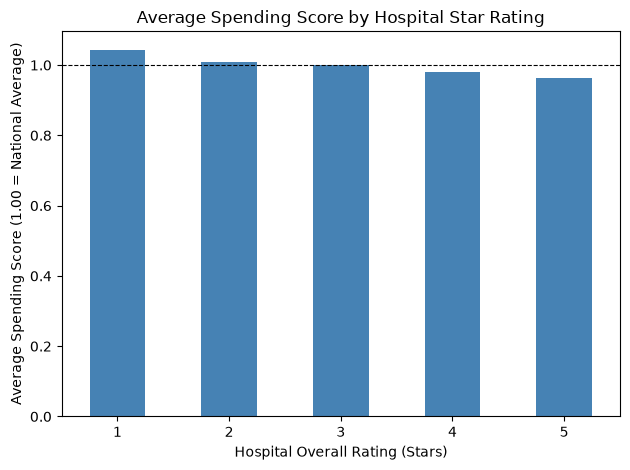

In [24]:
import matplotlib.pyplot as plt

rating_vs_spending.plot(kind="bar", color="steelblue")
plt.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
plt.title("Average Spending Score by Hospital Star Rating")
plt.xlabel("Hospital Overall Rating (Stars)")
plt.ylabel("Average Spending Score (1.00 = National Average)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/spending_by_rating.png", bbox_inches="tight")
plt.show()


**Reading this chart:** a clean, steady staircase down from 1-star to 5-star hospitals, crossing the national-average line (dashed) right between 3 and 4 stars. Nothing jagged or random about it — the pattern holds at every step.

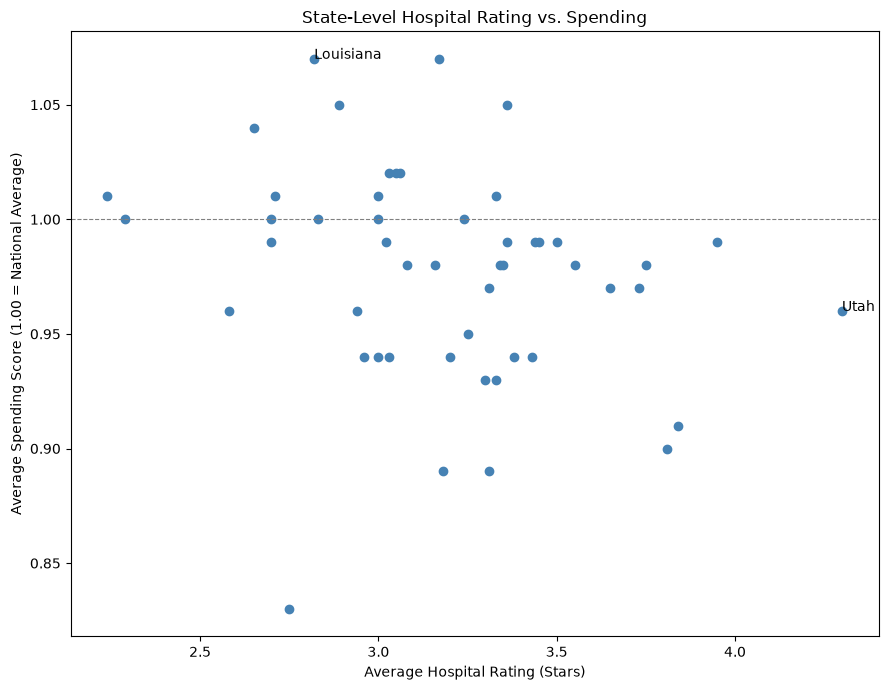

In [25]:
plt.figure(figsize=(9, 7))
plt.scatter(state_summary["Hospital overall rating"], state_summary["Score"], color="steelblue")
plt.axhline(1.0, color="gray", linewidth=0.8, linestyle="--")

plt.annotate("Utah", (state_summary.loc["UT", "Hospital overall rating"], state_summary.loc["UT", "Score"]))
plt.annotate("Louisiana", (state_summary.loc["LA", "Hospital overall rating"], state_summary.loc["LA", "Score"]))

plt.xlabel("Average Hospital Rating (Stars)")
plt.ylabel("Average Spending Score (1.00 = National Average)")
plt.title("State-Level Hospital Rating vs. Spending")
plt.tight_layout()
plt.savefig("../images/state_rating_vs_spending.png", bbox_inches="tight")
plt.show()


**Reading this chart:** real scatter and noise around the trend, not a perfectly clean diagonal line — exactly what a weak-to-moderate -0.23 correlation should look like. But the general drift is visible: most high-spending states (top of the chart) sit toward the left (lower ratings), most low-spending states (bottom) sit more toward the right. Utah sits clearly apart from the crowd, in the bottom-right corner — high rating, below-average spending. Louisiana sits near the top, spending well above average without a matching rating.

Exporting the cleaned, joined table so the same analysis could be rebuilt as an interactive Power BI dashboard.

In [26]:
combined.to_csv("../data/hospital_quality_spending_combined.csv", index=False)


## 6. Conclusion

**Higher-rated hospitals spend less per patient, not more** — a real, consistent relationship (-0.228 hospital-level, -0.234 state-level), though weak-to-moderate in strength, not dominant. Utah, Wisconsin, and Minnesota show that high quality and below-average spending can coexist; Louisiana and New Jersey show the opposite pattern — high spending without a matching quality payoff. This finding was rebuilt and independently verified in Power BI (correlation -0.23 via a DAX measure, matching the Python result), and turned into an interactive dashboard. Full findings, recommendations, and limitations are documented in [`README.md`](../README.md).